# Titanic Survival Prediction with Random Forest

**Student:** Temur Rustamov c00280204
**Item:** Titanic Survival Classification (Random Forest+Custom Preprocessing)

## Project Overview

In this notebook I build a machine learning model to predict whether a passenger on the Titanic **survived (1)** or **did not survive (0)** based on features such as class, sex, age.

The goal is to demonstrate an e2e supervised learning pipeline handling missing values and categorical variables, building a preprocessing pipeline, training and tuning a **Random Forest classifier**

## Dataset & Why I Chose It
I chose the Titanic dataset because:
- The problem is easy to understand intuitively: who survived and why?

## Methodology

1. **Load and explore the data**
   - Plot a correlation heatmap to see which numerical features relate to survival.

2. **Stratified train/test split**
   - Use `StratifiedShuffleSplit` to create a train test split that preserves the distribution of `Survived`, `Pclass` and `Sex`.

3. **Custom preprocessing pipeline**
   - **AgeImputer** – fills missing `Age` values with the mean 
   - **FeatureEncoder** – one-hot encodes `Embarked` and `Sex` into numeric dummy variables
   - **FeatureDropper** – drops unused or high cardinality columns

4. **Feature scaling**
   - Use `StandardScaler` to scale numerical features before training

5. **Model training & hyperparameter tuning**
   - Train a **RandomForestClassifier** on the processed training data.
   - Perform a grid search

6. **Model evaluation**
   - Scale to the stratified test set.

## Key Findings

- **Sex** and **Pclass** are very strong predictors of survival: females and passengers in higher classes have a much higher survival rate.
- Simple preprocessing plus a **Random Forest** model already achieves **good accuracy** on the internal test split (as printed in the notebook).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Titanic training data
titanic_data = pd.read_csv("./data/train.csv")
titanic_data.head()  # first 5 rows


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [102]:
titanic_data.describe() #key stats about individuals

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


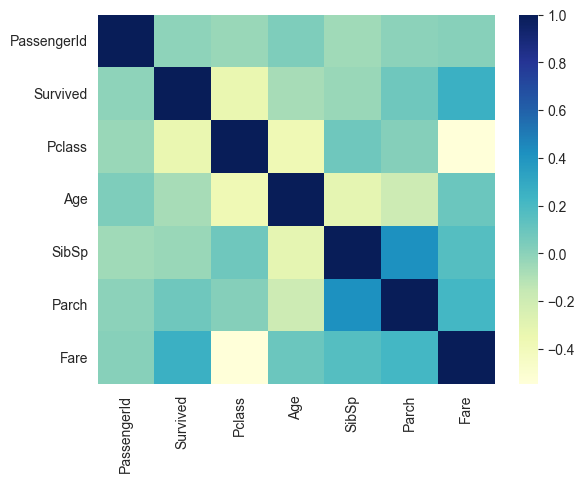

In [ ]:
# Correlation heatmap for numerical features
corr = titanic_data.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap="YlGnBu", annot=False)
plt.title("Correlation Matrix (Numerical Features)")
plt.show()


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

#  Create a stratified train test split
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_indices, test_indices in split.split(
    titanic_data, titanic_data[["Survived", "Pclass", "Sex"]]
):
    strat_train_set = titanic_data.loc[train_indices]
    strat_test_set = titanic_data.loc[test_indices]


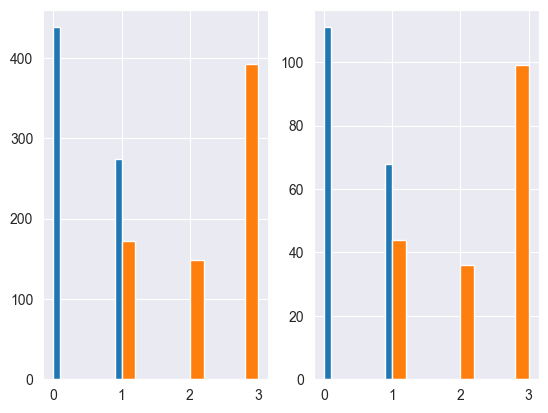

In [ ]:
# Compare histograms for train vs test distributions of key variables
plt.subplot(1, 2, 1)
strat_train_set["Survived"].hist()
strat_train_set["Pclass"].hist()
plt.title("Train set")

plt.subplot(1, 2, 2)
strat_test_set["Survived"].hist()
strat_test_set["Pclass"].hist()
plt.title("Test set")

plt.tight_layout()
plt.show()


In [ ]:
# Inspect training set structure and missing values
strat_train_set.info()


<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 741 to 856
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Name         712 non-null    object 
 4   Sex          712 non-null    object 
 5   Age          571 non-null    float64
 6   SibSp        712 non-null    int64  
 7   Parch        712 non-null    int64  
 8   Ticket       712 non-null    object 
 9   Fare         712 non-null    float64
 10  Cabin        163 non-null    object 
 11  Embarked     711 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 72.3+ KB


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer

# Custom transformer to fill missing Age values with the mean
class AgeImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        # Use SimpleImputer to fill missing Age values
        imputer = SimpleImputer(strategy="mean")
        X["Age"] = imputer.fit_transform(X[["Age"]])
        return X


In [ ]:
from sklearn.preprocessing import OneHotEncoder

#  Custom transformer to encode categorical features 
class FeatureEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        encoder = OneHotEncoder()
        # Encode Embarked and create columns C, S, Q, N (N = missing/other)
        matrix = encoder.fit_transform(X[["Embarked"]]).toarray()
        column_names = ["C", "S", "Q", "N"]
        for i in range(len(matrix.T)):
            X[column_names[i]] = matrix.T[i]
        matrix = encoder.fit_transform(X[["Sex"]]).toarray()
        column_names = ["Female", "Male"]

        for i in range(len(matrix.T)):
            X[column_names[i]] = matrix.T[i]

        return X


In [ ]:
# Custom transformer to drop unused
class FeatureDropper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop(
            ["Embarked", "Name", "Ticket", "Cabin", "Sex", "N"],
            axis=1,
            errors="ignore",
        )


In [110]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([('ageimputer', AgeImputer()),('featureencoder', FeatureEncoder()), ('featuredropper', FeatureDropper())])

In [111]:
strat_train_set = pipeline.fit_transform(strat_train_set)

In [112]:
strat_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 741 to 856
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Age          712 non-null    float64
 4   SibSp        712 non-null    int64  
 5   Parch        712 non-null    int64  
 6   Fare         712 non-null    float64
 7   C            712 non-null    float64
 8   S            712 non-null    float64
 9   Q            712 non-null    float64
 10  Female       712 non-null    float64
 11  Male         712 non-null    float64
dtypes: float64(7), int64(5)
memory usage: 72.3 KB


In [113]:
from sklearn.preprocessing import StandardScaler
X = strat_train_set.drop(['Survived'], axis=1)
y=strat_train_set['Survived']
scaler = StandardScaler()
X_data = scaler.fit_transform(X)
y_data = y.to_numpy()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

#  Define a Random Forest classifier and parameter grid for tuning
clf = RandomForestClassifier(random_state=42)

param_grid = [
    {
        "n_estimators": [10, 100, 200, 500],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 3, 4],
    }
]

# Grid search over hyperparameters, using accuracy as the scoring metric
grid_search = GridSearchCV(
    clf,
    param_grid,
    cv=3,
    scoring="accuracy",
    return_train_score=True,
)
grid_search.fit(X_data, y_data)


,estimator,RandomForestClassifier()
,param_grid,"[{'max_depth': [None, 5, ...], 'min_samples_split': [2, 3, ...], 'n_estimators': [10, 100, ...]}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,100


In [115]:
final_clf = grid_search.best_estimator_
final_clf

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,4
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [116]:
strat_test_set = pipeline.fit_transform(strat_test_set)
strat_test_set

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,C,S,Q,Female,Male
139,140,0,1,24.000000,0,0,79.2000,1.0,0.0,0.0,0.0,1.0
704,705,0,3,26.000000,1,0,7.8542,0.0,0.0,1.0,0.0,1.0
252,253,0,1,62.000000,0,0,26.5500,0.0,0.0,1.0,0.0,1.0
833,834,0,3,23.000000,0,0,7.8542,0.0,0.0,1.0,0.0,1.0
401,402,0,3,26.000000,0,0,8.0500,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
651,652,1,2,18.000000,0,1,23.0000,0.0,0.0,1.0,1.0,0.0
768,769,0,3,30.657343,1,0,24.1500,0.0,1.0,0.0,0.0,1.0
394,395,1,3,24.000000,0,2,16.7000,0.0,0.0,1.0,1.0,0.0
865,866,1,2,42.000000,0,0,13.0000,0.0,0.0,1.0,1.0,0.0


In [117]:
X_test = strat_test_set.drop(['Survived'], axis=1)
y_test = strat_test_set['Survived']

scaler = StandardScaler()
X_data_test = scaler.fit_transform(X_test)
y_data_test = y_test.to_numpy()
final_clf.score(X_data_test, y_data_test)

0.776536312849162

In [118]:
final_data = pipeline.fit_transform(titanic_data)
final_data

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,C,S,Q,Female,Male
0,1,0,3,22.000000,1,0,7.2500,0.0,0.0,1.0,0.0,1.0
1,2,1,1,38.000000,1,0,71.2833,1.0,0.0,0.0,1.0,0.0
2,3,1,3,26.000000,0,0,7.9250,0.0,0.0,1.0,1.0,0.0
3,4,1,1,35.000000,1,0,53.1000,0.0,0.0,1.0,1.0,0.0
4,5,0,3,35.000000,0,0,8.0500,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.000000,0,0,13.0000,0.0,0.0,1.0,0.0,1.0
887,888,1,1,19.000000,0,0,30.0000,0.0,0.0,1.0,1.0,0.0
888,889,0,3,29.699118,1,2,23.4500,0.0,0.0,1.0,1.0,0.0
889,890,1,1,26.000000,0,0,30.0000,1.0,0.0,0.0,0.0,1.0


In [ ]:
# Prepare features and target for the test set and evaluate the model
X_test = strat_test_set.drop(["Survived"], axis=1)
y_test = strat_test_set["Survived"]

scaler = StandardScaler()
X_data_test = scaler.fit_transform(X_test)
y_data_test = y_test.to_numpy()
final_clf.score(X_data_test, y_data_test)


In [ ]:
# Train a "production" Random Forest model on all available labelled data
prod_clf = RandomForestClassifier(random_state=42)

param_grid = [
    {
        "n_estimators": [10, 100, 200, 500],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 3, 4],
    }
]

grid_search = GridSearchCV(
    prod_clf,
    param_grid,
    cv=3,
    scoring="accuracy",
    return_train_score=True,
)
grid_search.fit(X_data_final, y_data_final)


,estimator,RandomForestClassifier()
,param_grid,"[{'max_depth': [None, 5, ...], 'min_samples_split': [2, 3, ...], 'n_estimators': [10, 100, ...]}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,200


In [121]:
prod_final_clf = grid_search.best_estimator_
prod_final_clf

,n_estimators,200
,criterion,'gini'
,max_depth,5
,min_samples_split,3
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [124]:
titanic_test_data = pd.read_csv('data/test.csv')
final_test_data = pipeline.fit_transform(titanic_test_data)

In [ ]:
# Prepare final test feature matrix and generate predictions
X_final_test = final_test_data
X_final_test = X_final_test.ffill()
scaler = StandardScaler()
X_data_final_test = scaler.fit_transform(X_final_test)
# Predict survival for each passenger in the test data
predictions = prod_final_clf.predict(X_data_final_test)


In [137]:
predictions

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [138]:
final_df = pd.DataFrame(titanic_test_data['PassengerId'])
final_df['Survived'] = predictions
final_df.to_csv('data/predictions.csv', index=False)

In [139]:
final_df

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0
